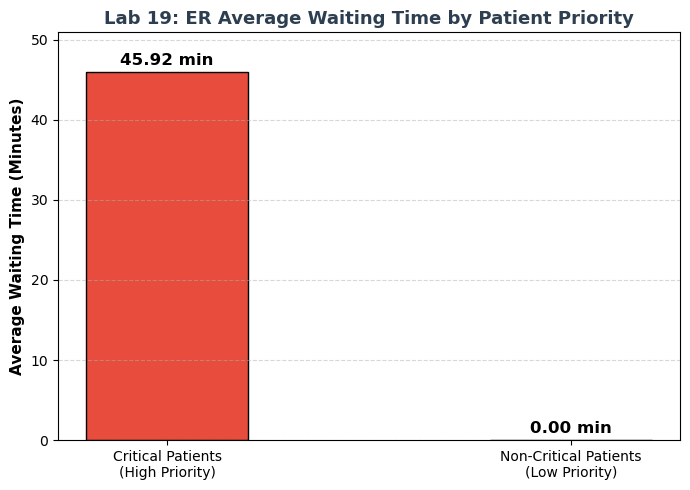

In [1]:
import random
import simpy
import numpy as np
import matplotlib.pyplot as plt


RANDOM_SEED = 42
SIM_TIME = 150         
ARRIVAL_RATE = 3.5     
TIME_TRIAGE = 2.0      
TIME_TREATMENT = 12.0  

NUM_NURSES = 1         
NUM_DOCTORS = 1        

critical_wait_times = []      
non_critical_wait_times = []  
rng = np.random.default_rng(RANDOM_SEED)


def patient(env, name, nurse, doctor):
    # ৩০% কাস্টমার গুরুতর (Priority=1), ৭০% সাধারণ (Priority=2)
    patient_priority = 1 if random.random() < 0.30 else 2
        
    with nurse.request() as req:
        yield req
        yield env.timeout(TIME_TRIAGE) 
        
  
    triage_done_time = env.now 
    with doctor.request(priority=patient_priority) as req:
        yield req 
        
        # অপেক্ষার সময় হিসাব ও লিস্টে জমা করা
        wait_time = env.now - triage_done_time
        if patient_priority == 1:
            critical_wait_times.append(wait_time)
        else:
            non_critical_wait_times.append(wait_time)
            
        yield env.timeout(rng.exponential(TIME_TREATMENT)) 

def patient_generator(env, nurse, doctor):
    p_id = 1
    while True:
        yield env.timeout(random.expovariate(1.0 / ARRIVAL_RATE))
        env.process(patient(env, f"Patient {p_id}", nurse, doctor))
        p_id += 1

# --- ৪. সিমুলেশন রান ---
random.seed(RANDOM_SEED)
env = simpy.Environment()
nurse_res = simpy.Resource(env, capacity=NUM_NURSES)
doctor_res = simpy.PriorityResource(env, capacity=NUM_DOCTORS) 

env.process(patient_generator(env, nurse_res, doctor_res))
env.run(until=SIM_TIME) 

# গড় সময় বের করা
avg_crit_wait = np.mean(critical_wait_times) if critical_wait_times else 0
avg_non_crit_wait = np.mean(non_critical_wait_times) if non_critical_wait_times else 0


plt.figure(figsize=(7, 5))
categories = ['Critical Patients\n(High Priority)', 'Non-Critical Patients\n(Low Priority)']
wait_times = [avg_crit_wait, avg_non_crit_wait]


bars = plt.bar(categories, wait_times, color=['#e74c3c', '#3498db'], edgecolor='black', width=0.4)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.2f} min", ha='center', va='bottom', fontsize=12, fontweight='bold')

# গ্রাফের লেবেল ও টাইটেল
plt.title("Lab 19: ER Average Waiting Time by Patient Priority", fontsize=13, fontweight='bold', color='#2c3e50')
plt.ylabel("Average Waiting Time (Minutes)", fontsize=11, fontweight='bold')
plt.ylim(0, max(wait_times) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()